# Exemplo Prático: K-Means e o Método do Cotovelo (Elbow)

Neste notebook, vamos:
1. Gerar um conjunto de dados artificiais.
2. Utilizar o Método do Cotovelo para encontrar o número ideal de clusters ($K$).
3. Aplicar o algoritmo K-Means utilizando a distância euclidiana para agrupar os dados e visualizar os centróides.

In [1]:
# Importar as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Configuração de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')

## Passo 1: Geração de Dados Sintéticos
Vamos criar um conjunto de 300 pontos de dados distribuídos em 4 grupos (clusters) distintos para simular um cenário real. Como nós é que estamos a criar os dados, já sabemos que o $K$ ideal será 4, mas vamos usar o algoritmo para descobrir isso de forma automática.

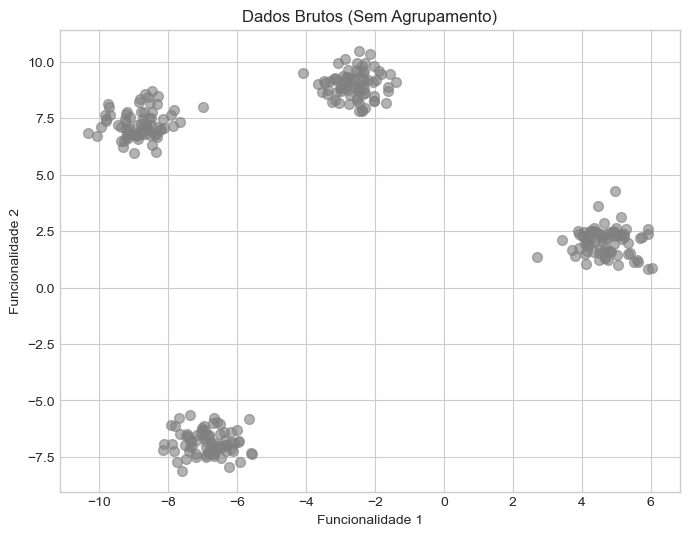

In [2]:
# Gerar dados artificiais
# n_samples = número de pontos, centers = número de grupos, cluster_std = dispersão
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Visualizar os dados originais (sem rótulos)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, color='gray', alpha=0.6)
plt.title('Dados Brutos (Sem Agrupamento)')
plt.xlabel('Funcionalidade 1')
plt.ylabel('Funcionalidade 2')
plt.show()

## Passo 2: O Método do Cotovelo (Elbow Method)
O algoritmo K-Means precisa de saber quantos clusters ($K$) deve procurar. Para isso, testamos vários valores de $K$ (por exemplo, de 1 a 10) e calculamos o **WCSS** (Soma dos Quadrados Intra-Cluster). O ponto onde a queda do WCSS abranda drasticamente (formando um "cotovelo") indica o $K$ ideal.

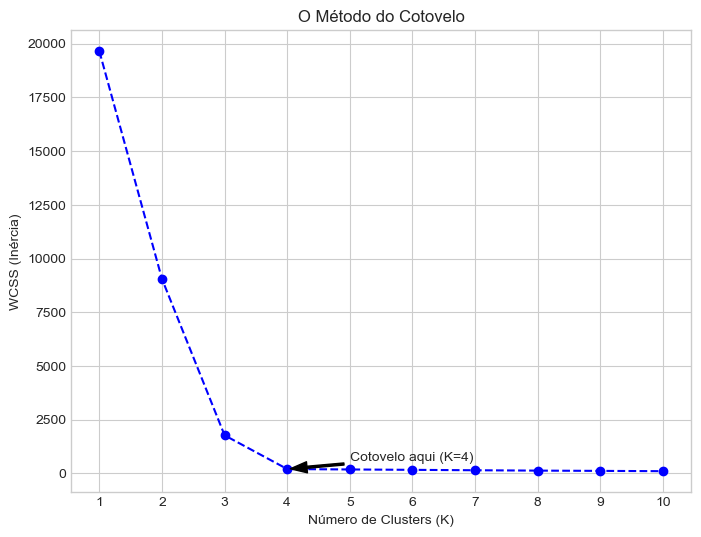

In [3]:
wcss = []
k_values = range(1, 11)

# Testar o K-Means para K de 1 a 10
for k in k_values:
    # n_init=10 é recomendado para evitar avisos de versões recentes do sklearn
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    # A inércia é o nosso WCSS (distância euclidiana ao quadrado dos pontos para o centróide)
    wcss.append(kmeans.inertia_)

# Plotar o gráfico do Método do Cotovelo
plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('O Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inércia)')
plt.xticks(k_values)
plt.annotate('Cotovelo aqui (K=4)', xy=(4, wcss[3]), xytext=(5, wcss[3] + 400),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
plt.show()

## Passo 3: Aplicar o K-Means com o K ideal
Observando o gráfico acima, é claro que a inflexão ocorre em $K=4$. Agora, vamos treinar o modelo definitivo e visualizar como ele agrupa os pontos e onde posiciona os centróides finais.

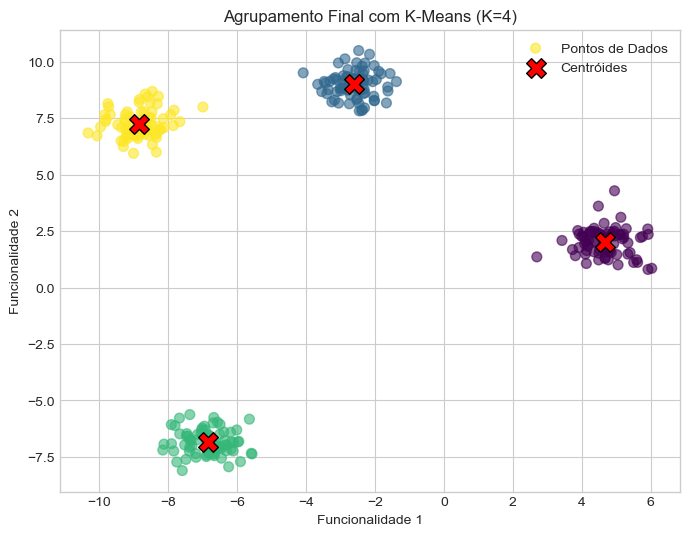

In [4]:
# Aplicar o K-Means com o número ideal de clusters (K=4)
kmeans_ideal = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans_ideal.fit_predict(X)

# Extrair as coordenadas finais dos centróides
centroides = kmeans_ideal.cluster_centers_

# Visualizar os clusters formados
plt.figure(figsize=(8, 6))

# Plotar os pontos coloridos por cluster
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.6, label='Pontos de Dados')

# Plotar os centróides
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Centróides')

plt.title('Agrupamento Final com K-Means (K=4)')
plt.xlabel('Funcionalidade 1')
plt.ylabel('Funcionalidade 2')
plt.legend()
plt.show()